# Flu Shot Learning: Predict H1N1 and Seasonal Flu Vaccines 
## Selected Method: Random Forest
### Module: Applied Machine Learning
### Lecturer: Manuel Benitez
### Student: Jose Ivan Lupian Calderon
### Student ID: 25037420

## Data Loading and Exploration

In [3]:
# Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.ensemble import RandomForestClassifier
from sklearn.multioutput import MultiOutputClassifier
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import roc_auc_score, f1_score,precision_score,recall_score,classification_report,confusion_matrix,roc_curve,auc

In [5]:
from ydata_profiling import ProfileReport

df = pd.read_csv(r'C:\Users\ivan_\Desktop\Data Analytics\Applied ML\AML_CA1\Datasets\training_set_features.csv',index_col='respondent_id')
profile = ProfileReport(df, title="Profiling Report")

In [ ]:
# Setting random seed

STUDENT_ID = 25037420
np.random.seed(STUDENT_ID)

# OUTPUT_DIR = r'C:\Users\ivan_\Desktop\Data Analytics\Applied ML\AML_CA1\Graphs'     # Only for saving charts in local storage
# os.makedirs(OUTPUT_DIR,exist_ok=True)

# def save_fig(filename):
#     plt.savefig(os.path.join(OUTPUT_DIR,filename),dpi=150,bbox_inches='tight')
#     print(f'[Saved]{filename}')

In [4]:
# Load Data

# Features as in original file / Setting 'respondent_id as the row index
features = pd.read_csv(r'C:\Users\ivan_\Desktop\Data Analytics\Applied ML\AML_CA1\Datasets\training_set_features.csv',index_col='respondent_id')

# Labels as in original file
labels = pd.read_csv(r'C:\Users\ivan_\Desktop\Data Analytics\Applied ML\AML_CA1\Datasets\training_set_labels.csv',index_col='respondent_id')

# Competition test set — no labels, used to generate final submission
test_raw = pd.read_csv(r'C:\Users\ivan_\Desktop\Data Analytics\Applied ML\AML_CA1\Datasets\test_set_features.csv',index_col='respondent_id')

# Mergin tables
df = features.join(labels)

print('Features shape: ', features.shape)
print('Labels shape: ', labels.shape)
print('Test set shape: ', test_raw.shape)
print('Merged df shape: ', df.shape)
df.head()

Features shape:  (26707, 35)
Labels shape:  (26707, 2)
Test set shape:  (26708, 35)
Merged df shape:  (26707, 37)


,h1n1_concern,h1n1_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,doctor_recc_h1n1,...,rent_or_own,employment_status,hhs_geo_region,census_msa,household_adults,household_children,employment_industry,employment_occupation,h1n1_vaccine,seasonal_vaccine
respondent_id,,,,,,,,,,,,,,,,,,,,,
0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,...,Own,Not in Labor Force,oxchjgsf,Non-MSA,0.0,0.0,NaN,NaN,0,0
1,3.0,2.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,...,Rent,Employed,bhuqouqj,"MSA, Not Principle City",0.0,0.0,pxcmvdjn,xgwztkwe,0,1
2,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,NaN,...,Own,Employed,qufhixun,"MSA, Not Principle City",2.0,0.0,rucpziij,xtkaffoo,0,0
3,1.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,...,Rent,Not in Labor Force,lrircsnp,"MSA, Principle City",0.0,0.0,NaN,NaN,0,1
4,2.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,...,Own,Employed,qufhixun,"MSA, Not Principle City",1.0,0.0,wxleyezf,emcorrxb,0,0


In [5]:
# Knowing the data type of each column

print('Data type:')
print(df.dtypes)

Data type:
h1n1_concern                   float64
h1n1_knowledge                 float64
behavioral_antiviral_meds      float64
behavioral_avoidance           float64
behavioral_face_mask           float64
behavioral_wash_hands          float64
behavioral_large_gatherings    float64
behavioral_outside_home        float64
behavioral_touch_face          float64
doctor_recc_h1n1               float64
doctor_recc_seasonal           float64
chronic_med_condition          float64
child_under_6_months           float64
health_worker                  float64
health_insurance               float64
opinion_h1n1_vacc_effective    float64
opinion_h1n1_risk              float64
opinion_h1n1_sick_from_vacc    float64
opinion_seas_vacc_effective    float64
opinion_seas_risk              float64
opinion_seas_sick_from_vacc    float64
age_group                       object
education                       object
race                            object
sex                             object
income_poverty

In [6]:
# Knowing the missing values only in the column where apply this condition

print('Missing values per column:')
print(df.isnull().sum()[df.isnull().sum()>0])

Missing values per column:
h1n1_concern                      92
h1n1_knowledge                   116
behavioral_antiviral_meds         71
behavioral_avoidance             208
behavioral_face_mask              19
behavioral_wash_hands             42
behavioral_large_gatherings       87
behavioral_outside_home           82
behavioral_touch_face            128
doctor_recc_h1n1                2160
doctor_recc_seasonal            2160
chronic_med_condition            971
child_under_6_months             820
health_worker                    804
health_insurance               12274
opinion_h1n1_vacc_effective      391
opinion_h1n1_risk                388
opinion_h1n1_sick_from_vacc      395
opinion_seas_vacc_effective      462
opinion_seas_risk                514
opinion_seas_sick_from_vacc      537
education                       1407
income_poverty                  4423
marital_status                  1408
rent_or_own                     2042
employment_status               1463
household_a

In [7]:
# Select target columns and round it to 3 decimals

print('Target distribution (mean):')
print(df[['h1n1_vaccine','seasonal_vaccine']].mean().round(3))

Target distribution (mean):
h1n1_vaccine        0.212
seasonal_vaccine    0.466
dtype: float64


## Visualisation

### Univariate

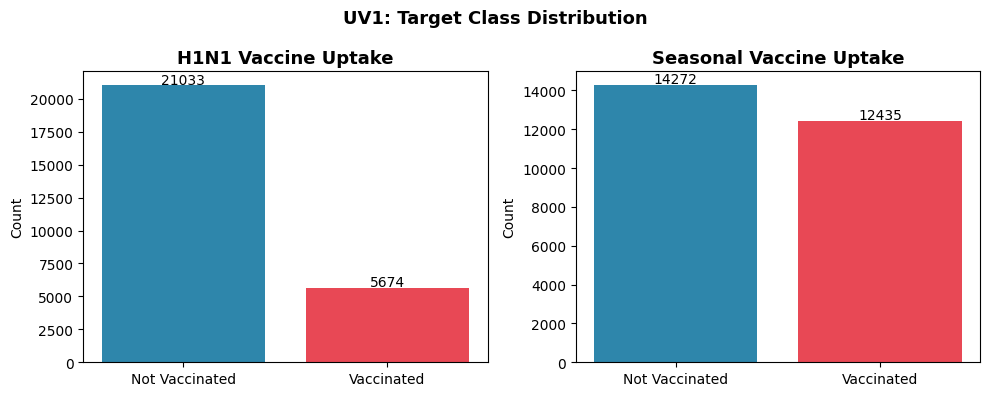

Insight: H1N1 uptake is only 21%, means a critical imbalance class


In [8]:
# UV1: Target class distribution

PALLETE = ['#2E86AB','#E84855'] # Setting colours for better visualisation

fig, axes = plt.subplots(1,2, figsize=(10,4))
for ax,col,title in zip(axes,                                               # Loop for pairing axis with target columns
                        ['h1n1_vaccine','seasonal_vaccine'],
                        ['H1N1 Vaccine Uptake','Seasonal Vaccine Uptake']):
    counts = df[col].value_counts()
    ax.bar(['Not Vaccinated','Vaccinated'],counts.values,color=PALLETE)
    ax.set_title(title,fontsize=13, fontweight='bold')
    ax.set_ylabel('Count')
    for i, v in enumerate(counts.values):                                   # Loop for exact count as label
        ax.text(i,v+100,str(v),ha='center',fontsize=10)
plt.suptitle('UV1: Target Class Distribution',fontsize=13,fontweight='bold')
plt.tight_layout()
# save_fig('uv1_target_distribution.png')                                   # Only for PDF purposes
plt.show()
print('Insight: H1N1 uptake is only 21%, means a critical imbalance class')

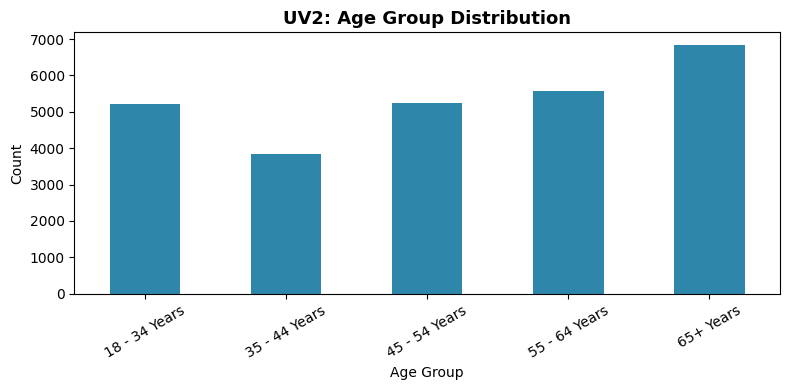

Insight: Older age group are more present


In [9]:
# UV2: Age group distribution

fig,ax = plt.subplots(figsize=(8,4))
df['age_group'].value_counts().sort_index().plot(kind='bar',color='#2E86AB',ax=ax) # Count of representants per group
ax.set_title('UV2: Age Group Distribution',fontsize=13,fontweight='bold')
ax.set_xlabel('Age Group')
ax.set_ylabel('Count')
plt.xticks(rotation=30)
plt.tight_layout()
# save_fig('uv2_age_group.png')
plt.show()
print('Insight: Older age group are more present')

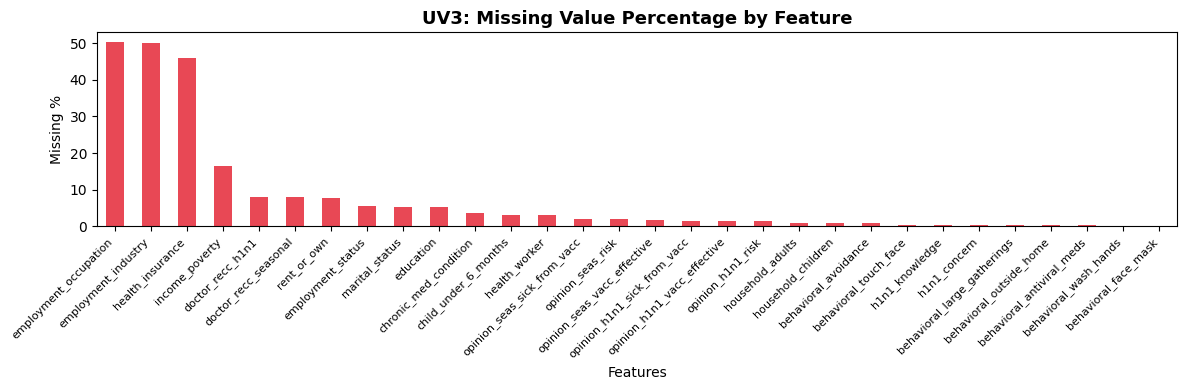

Insight: health_insurance, employment_industry and employmen_occupation present over 45% missing values


In [10]:
# UV3: Missing values percentage per feature

fig,ax = plt.subplots(figsize=(12,4))
missing_val = (df.isnull().sum()/len(df)*100).sort_values(ascending=False)      # Sum the total of missing values, divided by the total and multiplies by 100 to get percentage
missing_val = missing_val[missing_val>0]
missing_val.plot(kind='bar',color='#E84855',ax=ax)
ax.set_title('UV3: Missing Value Percentage by Feature',fontsize=13,fontweight='bold')
ax.set_ylabel('Missing %')
ax.set_xlabel('Features')
plt.xticks(rotation=45,ha='right',fontsize=8)
plt.tight_layout()
# save_fig('uv3_missing_values.png')
plt.show()
print('Insight: health_insurance, employment_industry and employmen_occupation present over 45% missing values')

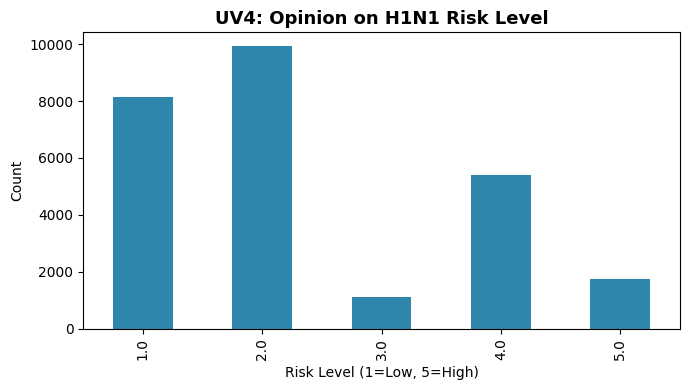

Insight: Most respondents rated H1N1 risk as low with a common answer of 2


In [11]:
# UV4: H1N1 risk opinion distribution

fig,ax = plt.subplots(figsize=(7,4))
df['opinion_h1n1_risk'].value_counts().sort_index().plot(kind='bar',color='#2E86AB',ax=ax)
ax.set_title('UV4: Opinion on H1N1 Risk Level',fontsize=13,fontweight='bold')
ax.set_xlabel('Risk Level (1=Low, 5=High)')
ax.set_ylabel('Count')
plt.tight_layout()
# save_fig('uv4_h1n1_risk_opinion.png')
plt.show()
print('Insight: Most respondents rated H1N1 risk as low with a common answer of 2')

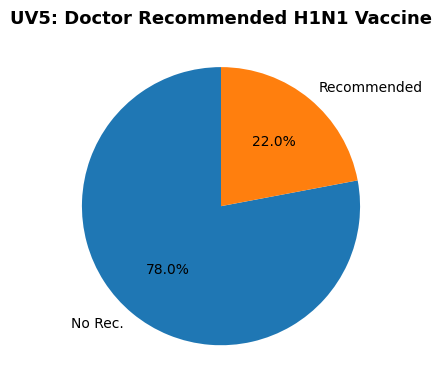

Insight: Only 23.5% received a doctor recommendation


In [12]:
# UV5: Doctor recomendation for H1N1 vaccine

fig,ax = plt.subplots(figsize=(6,4))
df['doctor_recc_h1n1'].value_counts().plot(kind='pie',labels=['No Rec.','Recommended'],
                                           autopct='%1.1f%%',color=PALLETE,ax=ax,startangle=90) # Autopct used to show percentage with decimals
ax.set_title('UV5: Doctor Recommended H1N1 Vaccine',fontsize=13,fontweight='bold')
ax.set_ylabel('')
plt.tight_layout()
# save_fig('uv5_doctor_recommendation.png')
plt.show()
print('Insight: Only 23.5% received a doctor recommendation')

### Complex

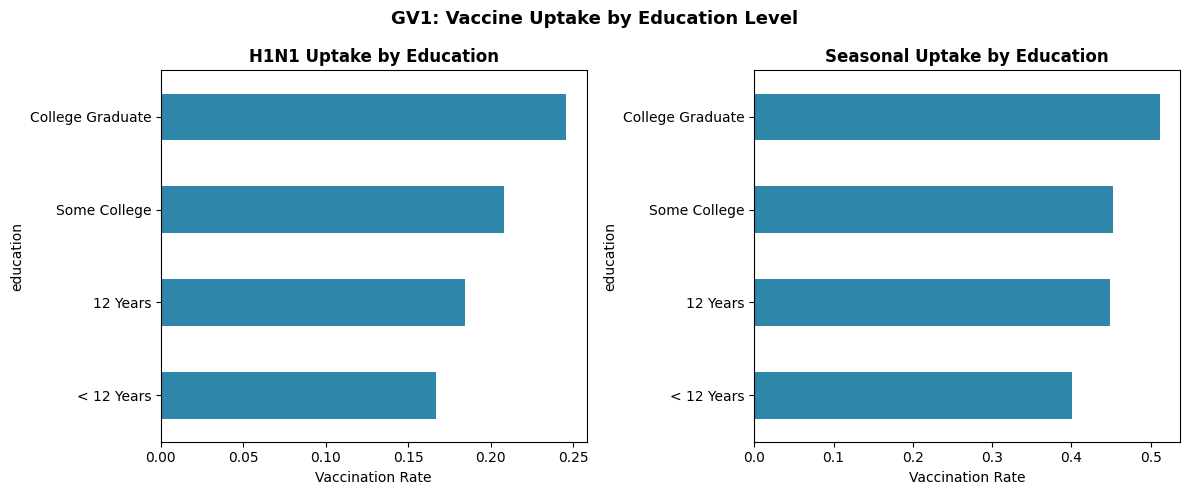

Insight: Higher education shows higher uptake rate for both vaccines


In [13]:
# GV1: Vaccine uptake by education level

fig,axes = plt.subplots(1,2,figsize=(12,5))                                             # Loop for pairing axis with target columns

for ax,col,title in zip(axes,
                        ['h1n1_vaccine','seasonal_vaccine'],
                        ['H1N1 Uptake by Education','Seasonal Uptake by Education']):
                        edu_rate = df.groupby('education')[col].mean().sort_values()    # Group data by educational level
                        edu_rate.plot(kind='barh',ax=ax,color='#2E86AB')
                        ax.set_title(title,fontsize=12,fontweight='bold')
                        ax.set_xlabel('Vaccination Rate')
plt.suptitle('GV1: Vaccine Uptake by Education Level',fontsize=13,fontweight='bold')
plt.tight_layout()
# save_fig('gv1_education_level.png')
plt.show()
print('Insight: Higher education shows higher uptake rate for both vaccines')

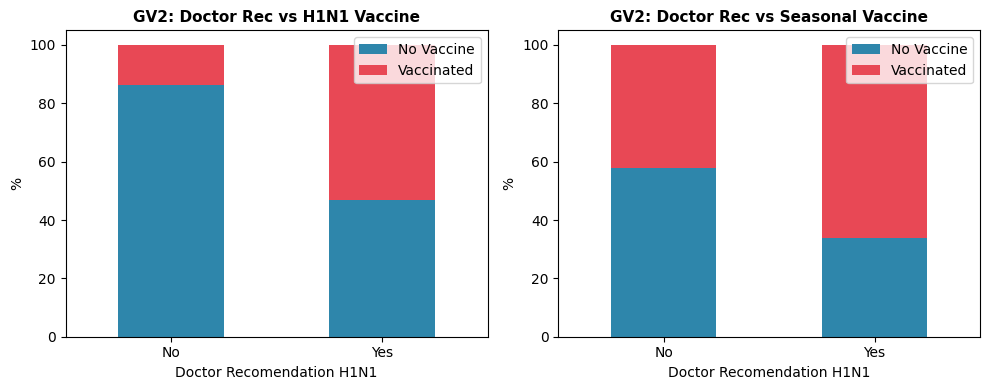

Insight: Doctor recomendation has a significant impact by 3 times uptake


In [14]:
# GV2: Doctor recommendation vs vaccine uptake

fig,axes = plt.subplots(1,2,figsize=(10,4))

for ax,col,title in zip(axes,
                        ['h1n1_vaccine','seasonal_vaccine'],
                        ['H1N1 Vaccine','Seasonal Vaccine']):
    cross_tab = pd.crosstab(df['doctor_recc_h1n1'],df[col],normalize='index')*100
    cross_tab.plot(kind='bar',stacked=True,ax=ax,color=PALLETE)
    ax.set_title(f'GV2: Doctor Rec vs {title}',fontsize=11,fontweight='bold')
    ax.set_xlabel('Doctor Recomendation H1N1')
    ax.set_ylabel('%')
    ax.legend(['No Vaccine','Vaccinated'])
    ax.set_xticklabels(['No','Yes'],rotation=0)
plt.tight_layout()
# save_fig('gv2_doctor_rec_vaccine.png')
plt.show()
print('Insight: Doctor recomendation has a significant impact by 3 times uptake')

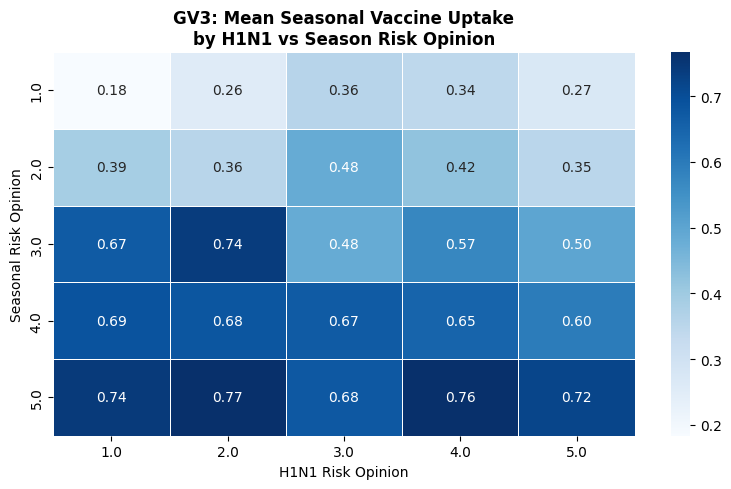

Insight: Rating both high risk at >70%


In [15]:
# GV3: Risk opinion heatmap

fig,ax = plt.subplots(figsize=(8,5))
pivot = df.pivot_table(values='seasonal_vaccine',                   # Summarize the grid format by creating a pivot variable
                       index='opinion_seas_risk',
                       columns='opinion_h1n1_risk',
                       aggfunc='mean')                              # Shows the mean for each parameter
sns.heatmap(pivot,annot=True,fmt='.2f',cmap='Blues',ax=ax,linewidths=.5)
ax.set_title('GV3: Mean Seasonal Vaccine Uptake\nby H1N1 vs Season Risk Opinion',fontsize=12,fontweight='bold')
ax.set_xlabel('H1N1 Risk Opinion')
ax.set_ylabel('Seasonal Risk Opinion')
plt.tight_layout()
# save_fig('gv3_risk_heatmap.png')
plt.show()
print('Insight: Rating both high risk at >70%')

C:\Users\ivan_\AppData\Local\Temp\ipykernel_24584\1443109323.py:9: UserWarning: Legend does not support handles for str instances.
A proxy artist may be used instead.
See: https://matplotlib.org/stable/users/explain/axes/legend_guide.html#controlling-the-legend-entries
  ax.legend('H1N1','Seasonal')


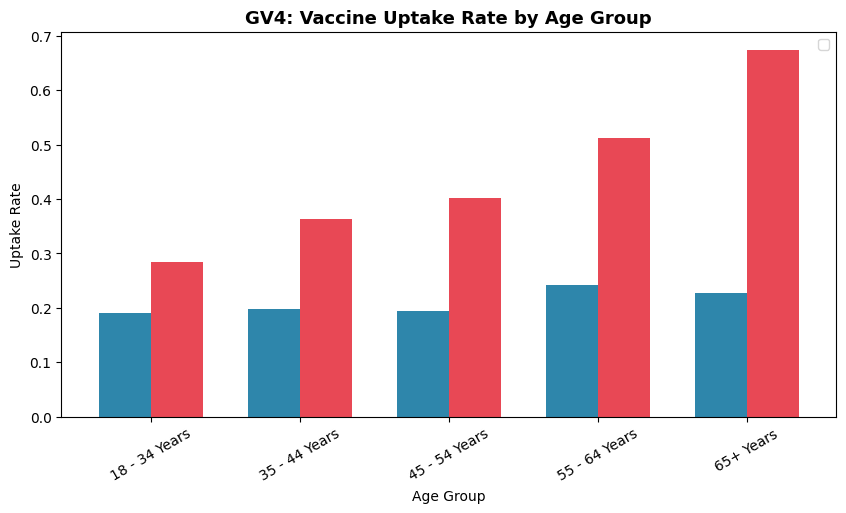

Insight: Vaccine uptake increases within the range of age for both targets


In [16]:
# GV4: Vaccine uptake by age group

fig,ax = plt.subplots(figsize=(10,5))
age_vac = df.groupby('age_group')[['h1n1_vaccine','seasonal_vaccine']].mean()       # Data grouped by age and calculated mean
age_vac.plot(kind='bar',ax=ax,color=PALLETE,width=0.7)
ax.set_title('GV4: Vaccine Uptake Rate by Age Group',fontsize=13,fontweight='bold')
ax.set_xlabel('Age Group')
ax.set_ylabel('Uptake Rate')
ax.legend('H1N1','Seasonal')
plt.xticks(rotation=30)
# save_fig('gv4_age_vaccine.png')
plt.show()
print('Insight: Vaccine uptake increases within the range of age for both targets')

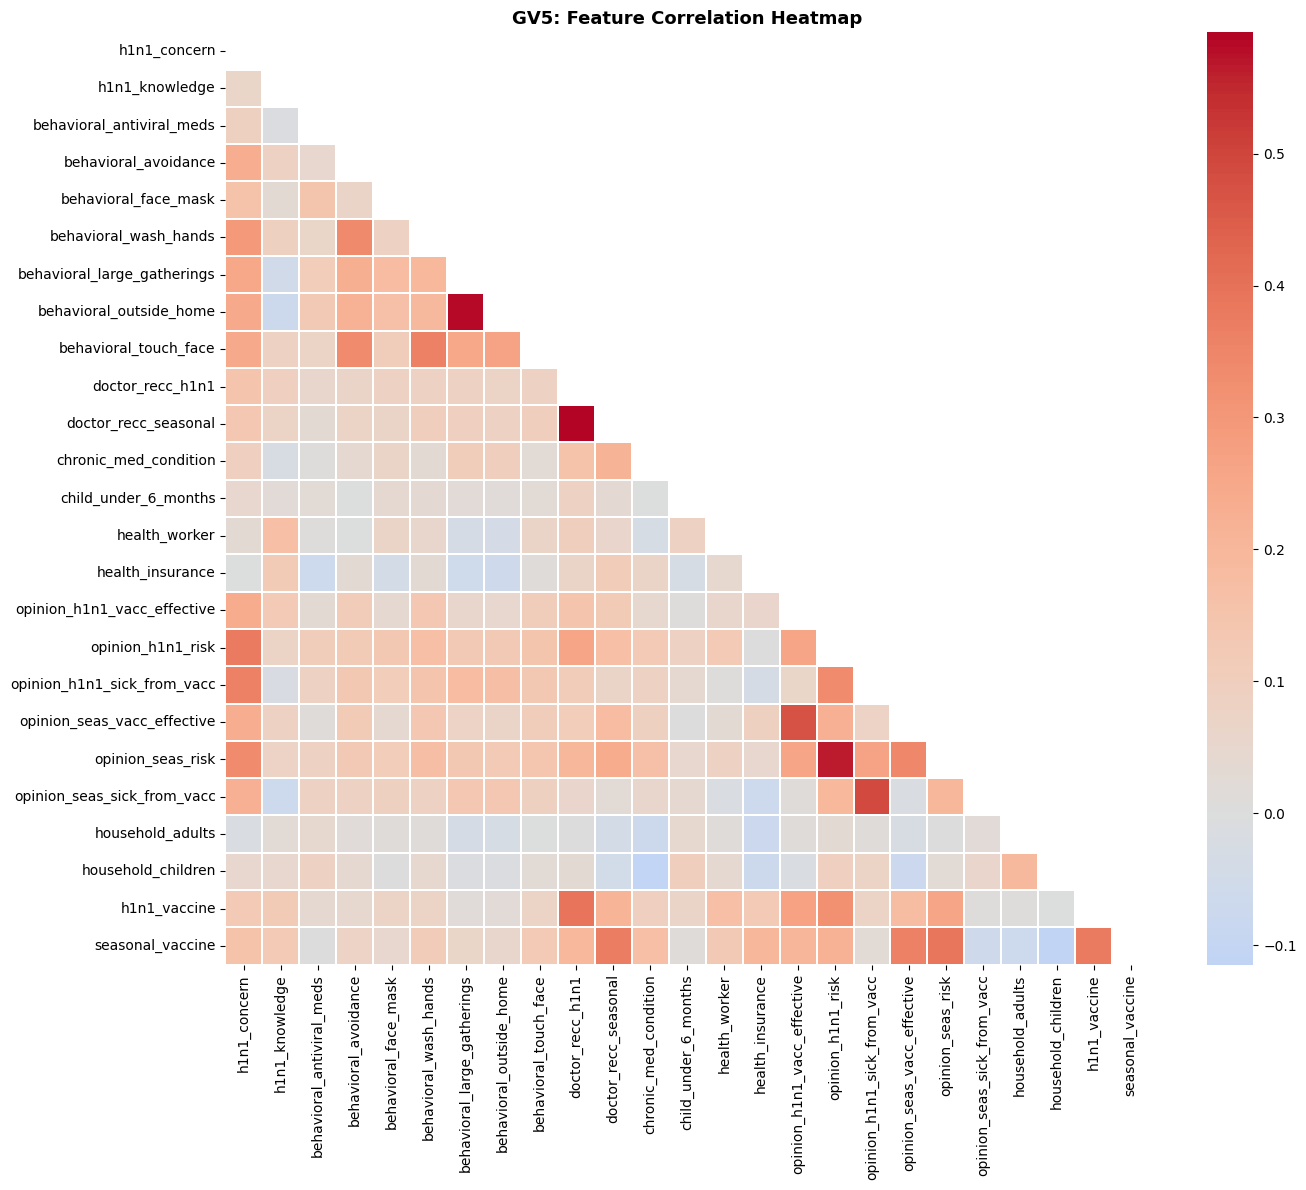

Insight: Both vaccines are positively corralated


In [17]:
# GV5: Feature correlation heatmap

numeric_cols = [c for c in df.select_dtypes(include=np.number).columns] # Create a list with only numerical columns
fig,ax = plt.subplots(figsize=(14,12))
corr = df[numeric_cols].corr()
matr = np.triu(np.ones_like(corr,dtype=bool))                           # Boolean mask to hide the upper triangle of the matrix
sns.heatmap(corr,mask=matr,cmap='coolwarm',center=0, annot=False,linewidths=0.3,ax=ax)
ax.set_title('GV5: Feature Correlation Heatmap',fontsize=13,fontweight='bold')
plt.tight_layout()
# save_fig('gv5_correlation_heatmap.png')
plt.show()
print('Insight: Both vaccines are positively corralated')

## Data Preprocessing

### Features and Labels

In [18]:
target_colums = ['h1n1_vaccine','seasonal_vaccine']                 # Separate the two target columns that the model will predict

X_raw = df.drop(columns=target_colums)                              # Drop the target columns from the merge DataFrame
y = df[target_colums]                                               # Contains only the two target columns

cat_cols = X_raw.select_dtypes(include='object').columns.tolist()   # Identifies all categorical columns
num_cols = X_raw.select_dtypes(exclude='object').columns.tolist()   # Identifies all numerical colums

print(f'Numerical features:     {len(num_cols)}')
print(f'Categorical features:   {len(cat_cols)}')
print(f'X_raw shape:    {X_raw.shape}')
print(f'y shape:        {y.shape}')

Numerical features:     23
Categorical features:   12
X_raw shape:    (26707, 35)
y shape:        (26707, 2)


### Missing Values

In [19]:
num_imputer = SimpleImputer(strategy='median')          # Imputer replace all missing values with median
num_imputer.fit(X_raw[num_cols])

cat_imputer = SimpleImputer(strategy='most_frequent')   # Imputer replace all missing values with most frequent
cat_imputer.fit(X_raw[cat_cols])

,missing_values,nan
,strategy,'most_frequent'
,fill_value,None
,copy,True
,add_indicator,False
,keep_empty_features,False


### Categorical Encoding

In [20]:
encoders ={}
for col in cat_cols:         # Loop for every categorical column name in cat_cols
    le = LabelEncoder()      # Conversion of text into integers
    le.fit(X_raw[cat_cols].apply(lambda s: s.fillna('missing'))[col])   # Filling NaN values with 'missing' string
    encoders[col] = le

print(f'Columns encoded: {cat_cols}')

Columns encoded: ['age_group', 'education', 'race', 'sex', 'income_poverty', 'marital_status', 'rent_or_own', 'employment_status', 'hhs_geo_region', 'census_msa', 'employment_industry', 'employment_occupation']


### Define 'Preprocessing' Function

In [21]:
def preprocess(X_input):
    X_num = pd.DataFrame(                                   # Apply median imputation to numerical columns
        num_imputer.transform(X_input[num_cols]),
        columns=num_cols,
        index=X_input.index
    )
    X_cat_imp = pd.DataFrame(                               # Apply most frequent imputation to categorical columns
        cat_imputer.transform(X_input[cat_cols]),
        columns=cat_cols,
        index=X_input.index
    )
    X_cat_enc = X_cat_imp.copy()                            # Apply encoding label
    for col in cat_cols:                                    # Loop to apply this label to categorical column
        X_cat_enc[col]=X_cat_imp[col].map(
            lambda val: encoders[col].transform([val])[0]
            if val in encoders[col].classes_ else -1
        )
    return pd.concat([X_num,X_cat_enc],axis=1)              # Join both numerical and categorical columns

In [22]:
# Apply defined function to each to each training feature set and test set

X_processed = preprocess(X_raw)
test_processed = preprocess(test_raw)

# Descriptive of the new sets after imputation and join

print(f'Training features processed shape:  {X_processed.shape}')
print(f'Test set processed shape:           {test_processed.shape}')
print(f'Any NaN in training X:  {X_processed.isnull().sum().sum()}')
print(f'Any NaN in test X:      {test_processed.isnull().sum().sum()}')

Training features processed shape:  (26707, 35)
Test set processed shape:           (26708, 35)
Any NaN in training X:  0
Any NaN in test X:      0


## Data Split

In [23]:
# Using random seed as STUDENT_ID

# First split (20% of the data)
X_temporary,X_test,y_temporary,y_test = train_test_split(
    X_processed,y,
    test_size=0.2,
    random_state=STUDENT_ID,
    stratify=y['h1n1_vaccine']
)

# Secon split (20% of the 80% = 0.25 of the data)
X_train,X_val,y_train,y_val = train_test_split(
    X_temporary,y_temporary,
    test_size=0.25,
    random_state=STUDENT_ID,
    stratify=y_temporary['h1n1_vaccine']
)

print(f'X_train:    {X_train.shape}({len(X_train)/len(X_processed)*100:.2f}%)')
print(f'X_val:      {X_val.shape}({len(X_val)/len(X_processed)*100:.2f}%)')
print(f'X_test:     {X_test.shape}({len(X_test)/len(X_processed)*100:.2f}%)')
print(f'test_set:   {test_processed.shape}(No labels)')

X_train:    (16023, 35)(60.00%)
X_val:      (5342, 35)(20.00%)
X_test:     (5342, 35)(20.00%)
test_set:   (26708, 35)(No labels)


## Application of ML Model

In [24]:
# Baseline Random Forest classifier for H1N1 vaccine

rf_h1n1_base = RandomForestClassifier(
    n_estimators=100,                               # Number of decision trees, default point
    random_state=STUDENT_ID,                        # Reproducibility
    n_jobs=-1                                       # Use of CPU available
)
rf_h1n1_base.fit(X_train,y_train['h1n1_vaccine'])

# Baseline Random Forest classifier for Seasonl vaccine

rf_seasonal_base = RandomForestClassifier(
    n_estimators=100,
    random_state=STUDENT_ID,
    n_jobs=-1
)
rf_seasonal_base.fit(X_train,y_train['seasonal_vaccine'])

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [25]:
# Baseline predictions for H1N1

prob_h1n1_val_base = rf_h1n1_base.predict_proba(X_val)[:,1]
pred_h1n1_val_base = (prob_h1n1_val_base>0.5).astype(int)

roc_h1n1_base = roc_auc_score(y_val['h1n1_vaccine'],prob_h1n1_val_base)
f1_h1n1_base = f1_score(y_val['h1n1_vaccine'],pred_h1n1_val_base)
prec_h1n1_base = precision_score(y_val['h1n1_vaccine'],pred_h1n1_val_base)
rec_h1n1_base = recall_score(y_val['h1n1_vaccine'],pred_h1n1_val_base)

print('Baseline H1N1')
print('-'*40)
print(f'ROC-AUC:    {roc_h1n1_base:.4f}')
print(f'F1 score:   {f1_h1n1_base:.4f}')
print(f'Precision:  {prec_h1n1_base:.4f}')
print(f'Recall:     {rec_h1n1_base:.4f}')

Baseline H1N1
----------------------------------------
ROC-AUC:    0.8323
F1 score:   0.5257
Precision:  0.7041
Recall:     0.4194


In [26]:
# Baseline prediction for Seasonal

prob_seasonal_val_base = rf_seasonal_base.predict_proba(X_val)[:,1]
pred_seasonal_val_base = (prob_seasonal_val_base > 0.5).astype(int)

roc_seasonal_base = roc_auc_score(y_val['seasonal_vaccine'],prob_seasonal_val_base)
f1_seasonal_base = f1_score(y_val['seasonal_vaccine'],pred_seasonal_val_base)
prec_seasonal_base = precision_score(y_val['seasonal_vaccine'],pred_seasonal_val_base)
rec_seasonal_base = recall_score(y_val['seasonal_vaccine'],pred_seasonal_val_base)

print('Baseline Seasonal')
print('-'*40)
print(f'ROC-AUC:    {roc_seasonal_base:.4f}')
print(f'F1 score:   {f1_seasonal_base:.4f}')
print(f'Precision:  {prec_seasonal_base:.4f}')
print(f'Recall:     {rec_seasonal_base:.4f}')

Baseline Seasonal
----------------------------------------
ROC-AUC:    0.8529
F1 score:   0.7555
Precision:  0.7700
Recall:     0.7416


## GridSearchCV

In [27]:
param_grid_rf = {
    'estimator__n_estimators':[200,300,500],        # Maximized number of trees to minize variance
    'estimator__max_depth':[10,15,20,25,None],      # Depth
    'estimator__min_samples_split':[2,5],           # Min of samples to split an internal node
    'estimator__min_samples_leaf':[1,2],            # Min of samples to leaf node
}

print('Parameter defined:')
print(param_grid_rf)

Parameter defined:
{'estimator__n_estimators': [200, 300, 500], 'estimator__max_depth': [10, 15, 20, 25, None], 'estimator__min_samples_split': [2, 5], 'estimator__min_samples_leaf': [1, 2]}


In [28]:
# GridSearchCV for H1N1

rf_tuned_h1n1 = GridSearchCV(                                               # Hyperparameter
    MultiOutputClassifier(RandomForestClassifier(                           # Nesting RF into MultiOutputClassifier
        random_state=STUDENT_ID,                                            # Reproducibility
        n_jobs=-1,                                                          # Used all CPU cores available
        class_weight='balanced')),                                          # Imbalance compesation
    param_grid_rf,
    scoring='roc_auc',                                                      # Evaluation using ROC-AUC
    cv=StratifiedKFold(n_splits=5,shuffle=True,random_state=STUDENT_ID),    # Cross-validation
    n_jobs=-1,
    verbose=1,                                                              # Tracking by user
    refit=True                                                              # Retention after finding best parameters
)

rf_tuned_h1n1.fit(X_train,y_train[['h1n1_vaccine']])                        # Fitting model

print(f'Best params: {rf_tuned_h1n1.best_params_}')
print(f'Best CV ROC-AUC: {rf_tuned_h1n1.best_score_:.4f}')

Fitting 5 folds for each of 60 candidates, totalling 300 fits
Best params: {'estimator__max_depth': 15, 'estimator__min_samples_leaf': 2, 'estimator__min_samples_split': 2, 'estimator__n_estimators': 500}
Best CV ROC-AUC: 0.8301


In [29]:
# GridSearchCV for Seasonal
rf_tuned_seasonal = GridSearchCV(
    MultiOutputClassifier(RandomForestClassifier(
        random_state=STUDENT_ID,
        n_jobs=-1,
        class_weight='balanced')),
    param_grid_rf,
    scoring='roc_auc',
    cv=StratifiedKFold(n_splits=5,shuffle=True,random_state=STUDENT_ID),
    n_jobs=-1,
    verbose=1,
    refit=True
)

rf_tuned_seasonal.fit(X_train,y_train[['seasonal_vaccine']])

print(f'Best params: {rf_tuned_seasonal.best_params_}')
print(f'Best CV ROC-AUC: {rf_tuned_seasonal.best_score_:.4f}')

Fitting 5 folds for each of 60 candidates, totalling 300 fits
Best params: {'estimator__max_depth': 15, 'estimator__min_samples_leaf': 2, 'estimator__min_samples_split': 2, 'estimator__n_estimators': 500}
Best CV ROC-AUC: 0.8542


In [30]:
# Tuned predictions on H1N1 target

prob_h1n1_val_tuned = rf_tuned_h1n1.predict_proba(X_val)[0][:,1]                # Generates predicted probabilities
pred_h1n1_val_tuned = (prob_h1n1_val_tuned>0.5).astype(int)                     # Converts continuous into binary 

roc_h1n1_tuned = roc_auc_score(y_val['h1n1_vaccine'],prob_h1n1_val_tuned)       # Calculates ROC-AUC
f1_h1n1_tuned = f1_score(y_val['h1n1_vaccine'],pred_h1n1_val_tuned)             # Calculates F1 Score
prec_h1n1_tuned = precision_score(y_val['h1n1_vaccine'],pred_h1n1_val_tuned)    # Calculates Precision
rec_h1n1_tuned = recall_score(y_val['h1n1_vaccine'],pred_h1n1_val_tuned)        # Calculates Recall

print('Tuned H1N1')
print('-'*40)
print(f'ROC-AUC:    {roc_h1n1_tuned:.4f}')
print(f'F1 score:   {f1_h1n1_tuned:.4f}')
print(f'Precision:  {prec_h1n1_tuned:.4f}')
print(f'Recall:     {rec_h1n1_tuned:.4f}')

Tuned H1N1
----------------------------------------
ROC-AUC:    0.8397
F1 score:   0.5880
Precision:  0.6195
Recall:     0.5595


In [31]:
# Tuned predictions on Seasonal target

prob_seasonal_val_tuned = rf_tuned_seasonal.predict_proba(X_val)[0][:,1]
pred_seasonal_val_tuned = (prob_seasonal_val_tuned>0.5).astype(int)

roc_seasonal_tuned = roc_auc_score(y_val['seasonal_vaccine'],prob_seasonal_val_tuned)
f1_seasonal_tuned = f1_score(y_val['seasonal_vaccine'],pred_seasonal_val_tuned)
prec_seasonal_tuned = precision_score(y_val['seasonal_vaccine'],pred_seasonal_val_tuned)
rec_seasonal_tuned = recall_score(y_val['seasonal_vaccine'],pred_seasonal_val_tuned)

print('Tuned Seasonal')
print('-'*40)
print(f'ROC-AUC:    {roc_seasonal_tuned:.4f}')
print(f'F1 score:   {f1_h1n1_tuned:.4f}')
print(f'Precision:  {prec_seasonal_tuned:.4f}')
print(f'Recall:     {rec_seasonal_tuned:.4f}')

Tuned Seasonal
----------------------------------------
ROC-AUC:    0.8571
F1 score:   0.5880
Precision:  0.7590
Recall:     0.7609


## Results Summary

In [32]:
results = pd.DataFrame({
    'Model': ['Baseline','Tuned','Baseline','Tuned'],
    'Target': ['h1n1','h1n1','seasonal','seasonal'],
    'ROC-AUC': [roc_h1n1_base,roc_h1n1_tuned,roc_seasonal_base,roc_seasonal_tuned],
    'F1 Score': [f1_h1n1_base,f1_h1n1_tuned,f1_seasonal_base,f1_seasonal_tuned],
    'Precision': [prec_h1n1_base,prec_h1n1_tuned,prec_seasonal_base,prec_seasonal_tuned],
    'Recall': [rec_h1n1_base,rec_seasonal_tuned,rec_seasonal_base,rec_seasonal_tuned]
})
results[['ROC-AUC','F1 Score','Precision','Recall']] = (results[['ROC-AUC','F1 Score','Precision','Recall']].round(4))
print(results.to_string(index=False))

   Model   Target  ROC-AUC  F1 Score  Precision  Recall
Baseline     h1n1   0.8323    0.5257     0.7041  0.4194
   Tuned     h1n1   0.8397    0.5880     0.6195  0.7609
Baseline seasonal   0.8529    0.7555     0.7700  0.7416
   Tuned seasonal   0.8571    0.7599     0.7590  0.7609


### Classification Reports

In [33]:
# H1N1 Target

print('Baseline H1N1')
print(classification_report(y_val['h1n1_vaccine'],pred_h1n1_val_base, target_names=['Not Vaccinated','Vaccinated']))
print('-'*60)
print('Tuned H1N1')
print(classification_report(y_val['h1n1_vaccine'],pred_h1n1_val_tuned,target_names=['Not Vaccinated','Vaccinated']))

Baseline H1N1
                precision    recall  f1-score   support

Not Vaccinated       0.86      0.95      0.90      4207
    Vaccinated       0.70      0.42      0.53      1135

      accuracy                           0.84      5342
     macro avg       0.78      0.69      0.71      5342
  weighted avg       0.83      0.84      0.82      5342

------------------------------------------------------------
Tuned H1N1
                precision    recall  f1-score   support

Not Vaccinated       0.88      0.91      0.90      4207
    Vaccinated       0.62      0.56      0.59      1135

      accuracy                           0.83      5342
     macro avg       0.75      0.73      0.74      5342
  weighted avg       0.83      0.83      0.83      5342



In [34]:
# Seasonal Target

print('Baseline Seasonal')
print(classification_report(y_val['seasonal_vaccine'],pred_seasonal_val_base,target_names=['Not Vacccinated','Vaccinated']))
print('-'*60)
print('Tuned Seasonal')
print(classification_report(y_val['seasonal_vaccine'],pred_seasonal_val_tuned,target_names=['Not Vaccinated','Vaccinated']))

Baseline Seasonal
                 precision    recall  f1-score   support

Not Vacccinated       0.79      0.81      0.80      2900
     Vaccinated       0.77      0.74      0.76      2442

       accuracy                           0.78      5342
      macro avg       0.78      0.78      0.78      5342
   weighted avg       0.78      0.78      0.78      5342

------------------------------------------------------------
Tuned Seasonal
                precision    recall  f1-score   support

Not Vaccinated       0.80      0.80      0.80      2900
    Vaccinated       0.76      0.76      0.76      2442

      accuracy                           0.78      5342
     macro avg       0.78      0.78      0.78      5342
  weighted avg       0.78      0.78      0.78      5342



## Confusion Matrices

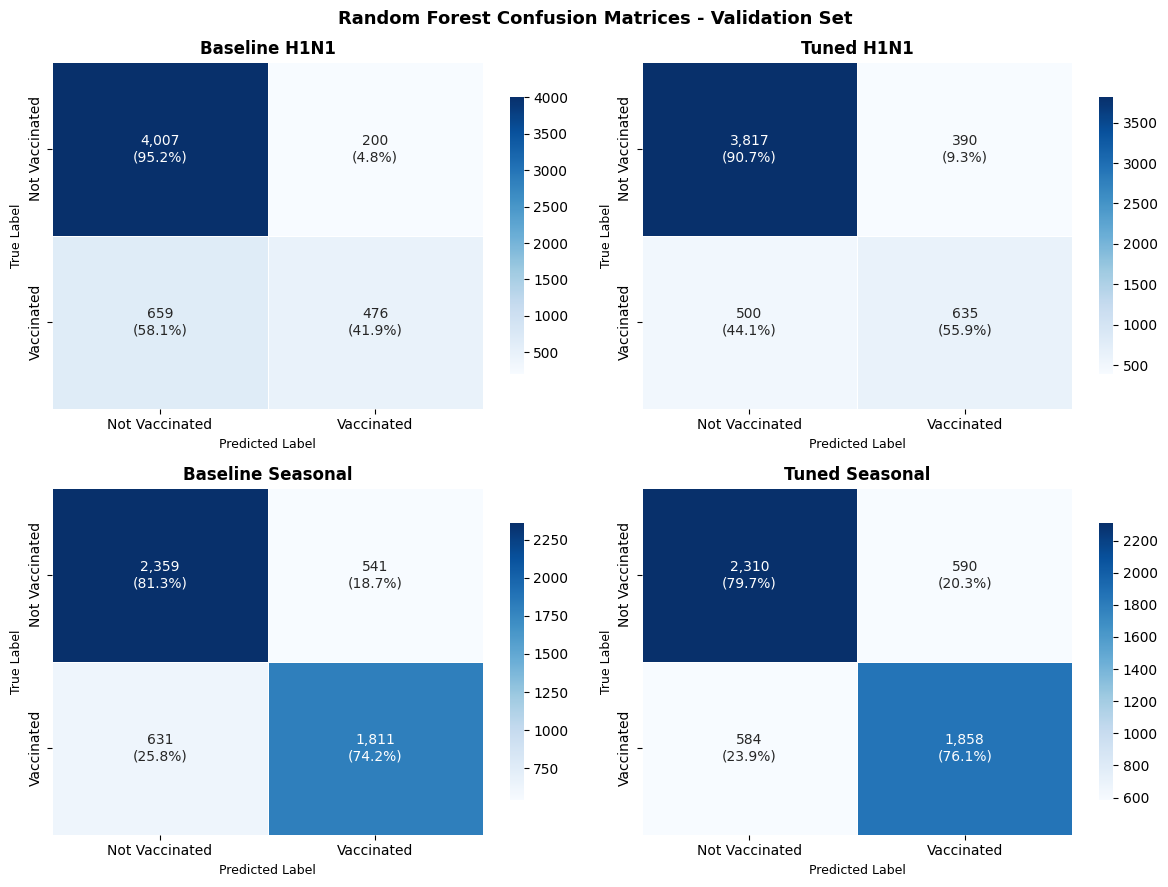

In [35]:
fig,axes = plt.subplots(2,2,figsize=(12,9))

configs = [
    (y_val['h1n1_vaccine'],pred_h1n1_val_base,'Baseline H1N1'),
    (y_val['h1n1_vaccine'],pred_h1n1_val_tuned, 'Tuned H1N1'),
    (y_val['seasonal_vaccine'],pred_seasonal_val_base,'Baseline Seasonal'),
    (y_val['seasonal_vaccine'],pred_seasonal_val_tuned,'Tuned Seasonal'),
]

for ax,(y_true,y_pred,title) in zip(axes.flatten(),configs):
    cm = confusion_matrix(y_true,y_pred)
    group_counts = [f'{v:,}' for v in cm.flatten()]
    group_pcts = [f'\n({v:.1%})' for v in (cm/cm.sum(axis=1,keepdims=True)).flatten()]
    annot_array = np.array([f'{c}{p}' for c, p in zip(group_counts,group_pcts)]).reshape(2,2)
    sns.heatmap(cm,annot=annot_array,fmt='',cmap='Blues',
                ax=ax, linewidths=0.5,linecolor='white',
                xticklabels=['Not Vaccinated','Vaccinated'],
                yticklabels=['Not Vaccinated','Vaccinated'],
                cbar_kws={'shrink':0.8})
    ax.set_title(title,fontsize=12,fontweight='bold')
    ax.set_xlabel('Predicted Label', fontsize=9)
    ax.set_ylabel('True Label',fontsize=9)
    ax.tick_params(axis='x')
    
plt.suptitle('Random Forest Confusion Matrices - Validation Set',
             fontsize=13,fontweight='bold')
plt.tight_layout()
# save_fig('rf_confusion_matrices.png')
plt.show()

## ROC Curves

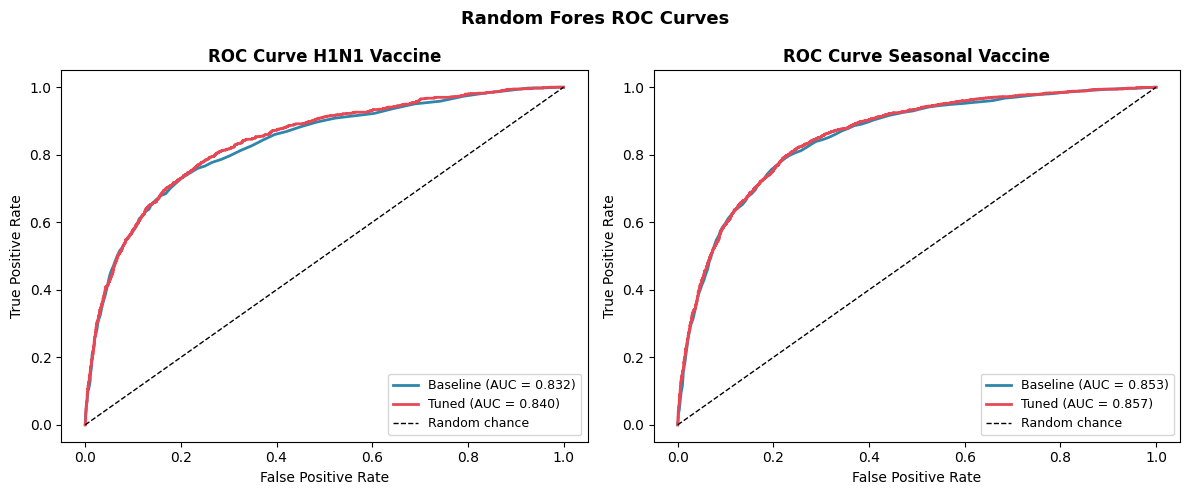

In [36]:
fig,axes = plt.subplots(1,2,figsize=(12,5))

configs = [
    (axes[0],'H1N1 Vaccine', y_val['h1n1_vaccine'],prob_h1n1_val_base,prob_h1n1_val_tuned),
    (axes[1],'Seasonal Vaccine',y_val['seasonal_vaccine'],prob_seasonal_val_base,prob_seasonal_val_tuned)
]

for ax,title,y_true,prob_base,prob_tuned in configs:
    for proba,label,color in [
        (prob_base,'Baseline','#2E86AB'),
        (prob_tuned,'Tuned','#E84855'),
    ]:
        fpr,tpr,_ = roc_curve(y_true,proba)
        roc_val = auc(fpr,tpr)
        ax.plot(fpr,tpr,color=color,lw=2,label=f'{label} (AUC = {roc_val:.3f})')
    ax.plot([0,1],[0,1],'k--',lw=1,label='Random chance')
    ax.set_title(f'ROC Curve {title}',fontsize=12,fontweight='bold')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.legend(loc='lower right',fontsize=9)

plt.suptitle('Random Fores ROC Curves',fontsize=13,fontweight='bold')
plt.tight_layout()
# save_fig('rf_roc_curves.png')
plt.show()

## Feature Importance

In [37]:
best_estimator_h1n1 = rf_tuned_h1n1.best_estimator_.estimators_[0]
feat_imp_df = pd.DataFrame({
    'Feature': X_processed.columns,
    'Importance': best_estimator_h1n1.feature_importances_
}).sort_values('Importance',ascending=False).head(15)

print(feat_imp_df.to_string(index=False))

                    Feature  Importance
           doctor_recc_h1n1    0.144617
          opinion_h1n1_risk    0.101186
opinion_h1n1_vacc_effective    0.089446
          opinion_seas_risk    0.060157
             hhs_geo_region    0.046713
      employment_occupation    0.041096
                  age_group    0.034183
opinion_seas_vacc_effective    0.034120
        employment_industry    0.031882
       doctor_recc_seasonal    0.030699
               h1n1_concern    0.027342
opinion_h1n1_sick_from_vacc    0.026857
opinion_seas_sick_from_vacc    0.025695
                  education    0.025220
              health_worker    0.022589


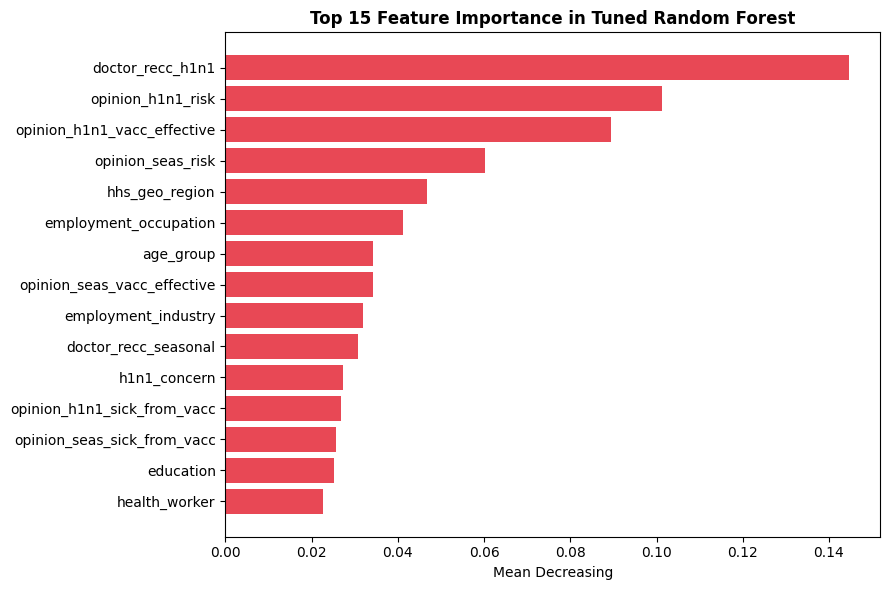

In [38]:
fig,ax = plt.subplots(figsize=(9,6))
ax.barh(feat_imp_df['Feature'][::-1],feat_imp_df['Importance'][::-1],color='#E84855')
ax.set_title('Top 15 Feature Importance in Tuned Random Forest',fontsize=12,fontweight='bold')
ax.set_xlabel('Mean Decreasing')
plt.tight_layout()
# save_fig('feature_importance.png')
plt.show()

## Test set final evaluation

In [39]:
prob_h1n1_test = rf_tuned_h1n1.predict_proba(X_test)[0][:,1]
prob_seasonal_test = rf_tuned_seasonal.predict_proba(X_test)[0][:,1]

pred_h1n1_test = (prob_h1n1_test >0.5).astype(int)
pred_seasonal_test = (prob_seasonal_test >0.5).astype(int)

test_result = pd.DataFrame({
    'Target': ['H1N1','Seasonal'],
    'ROC-AUC': [roc_auc_score(y_test['h1n1_vaccine'],prob_h1n1_test),
                roc_auc_score(y_test['seasonal_vaccine'],prob_seasonal_test)],
    'F1 score': [f1_score(y_test['h1n1_vaccine'],pred_h1n1_test),
                 f1_score(y_test['seasonal_vaccine'],pred_seasonal_test)],
    'Precision': [precision_score(y_test['h1n1_vaccine'],pred_h1n1_test),
                  precision_score(y_test['seasonal_vaccine'],pred_seasonal_test)],
    'Recall': [recall_score(y_test['h1n1_vaccine'],pred_h1n1_test),
               recall_score(y_test['seasonal_vaccine'],pred_seasonal_test)],
})

test_result[['ROC-AUC','F1 score','Precision','Recall']] = (test_result[['ROC-AUC','F1 score','Precision','Recall']].round(4))

print('Final evaluation for Tuned Random Forest')
print(test_result.to_string(index=False))

Final evaluation for Tuned Random Forest
  Target  ROC-AUC  F1 score  Precision  Recall
    H1N1   0.8414    0.5911     0.6310  0.5559
Seasonal   0.8578    0.7664     0.7721  0.7607
